## Tutorial for Applying SoccerCPD to kloppy Data

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import rpy2.robjects as robjects
import rpy2.robjects.packages as rpackages

from src.match import Match
from src.kloppy import Kloppy
from src.soccercpd import SoccerCPD

In [2]:
# robjects.r(".libPaths('/usr/lib/R/site-library')")
utils = rpackages.importr('utils')
utils.chooseCRANmirror(ind=1)
if not rpackages.isinstalled('gSeg'):
    utils.install_packages('gSeg')
rpackages.importr('gSeg')

rpy2.robjects.packages.Package as a <module 'gSeg'>

### Converting preprocessed RGP data into SoccerCPD format

In [3]:
home_id = 82977
away_id = 82981
data = pd.read_csv(f"data/kloppy/{home_id}-{away_id}.csv", header=0, parse_dates=["datetime"])
col_dict = {"index": "frame_id", "session": "period_id", "time": "timestamp"}
data = data.reset_index().rename(columns=col_dict)
data

,frame_id,datetime,period_id,timestamp,home_phase,home_03_x,home_03_y,home_03_speed,home_04_x,home_04_y,...,home_26_speed,home_32_x,home_32_y,home_32_speed,home_33_x,home_33_y,home_33_speed,home_34_x,home_34_y,home_34_speed
0,0,2024-10-25 04:57:33.000,1,0.0,1,-15.053311,-2.302143,0.532,NaN,NaN,...,NaN,-14.838519,-2.705626,0.097,NaN,NaN,NaN,-6.296431,-7.700478,0.194
1,1,2024-10-25 04:57:33.100,1,0.1,1,-15.053312,-2.288230,0.883,NaN,NaN,...,NaN,-14.821997,-2.733453,0.367,NaN,NaN,NaN,-6.312953,-7.700478,0.092
2,2,2024-10-25 04:57:33.200,1,0.2,1,-15.036789,-2.288230,0.570,NaN,NaN,...,NaN,-14.821997,-2.733453,0.269,NaN,NaN,NaN,-6.329476,-7.686565,0.459
3,3,2024-10-25 04:57:33.300,1,0.3,1,-15.036789,-2.302143,0.359,NaN,NaN,...,NaN,-14.821997,-2.733453,0.035,NaN,NaN,NaN,-6.345998,-7.686565,0.131
4,4,2024-10-25 04:57:33.400,1,0.4,1,-15.053312,-2.288230,0.457,NaN,NaN,...,NaN,-14.821996,-2.761279,0.275,NaN,NaN,NaN,-6.345998,-7.686565,0.214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45475,45475,2024-10-25 06:24:46.500,2,2372.5,5,12.968618,5.252750,4.450,3.385669,-2.886504,...,NaN,NaN,NaN,NaN,0.890787,-2.176928,0.702,NaN,NaN,NaN
45476,45476,2024-10-25 06:24:46.600,2,2372.6,5,12.968618,5.252750,4.450,3.385669,-2.900417,...,NaN,NaN,NaN,NaN,0.890787,-2.190841,0.545,NaN,NaN,NaN
45477,45477,2024-10-25 06:24:46.700,2,2372.7,5,12.968618,5.252750,4.450,3.402192,-2.914330,...,NaN,NaN,NaN,NaN,0.890787,-2.176928,0.133,NaN,NaN,NaN
45478,45478,2024-10-25 06:24:46.800,2,2372.8,5,12.968618,5.252750,4.450,3.402191,-2.886504,...,NaN,NaN,NaN,NaN,0.890787,-2.176928,0.200,NaN,NaN,NaN


In [4]:
kloppy = Kloppy(data)
kloppy.rotate_pitch()
input_data = kloppy.convert_to_soccercpd_input(exclude_gks=False)
input_data

,datetime,team,player_id,player_period,session,time,x,y,speed
0,2024-10-25 04:57:33.000,home,3,1,1,0.0,-15.053311,-2.302143,0.532
1,2024-10-25 04:57:33.100,home,3,1,1,0.1,-15.053312,-2.288230,0.883
2,2024-10-25 04:57:33.200,home,3,1,1,0.2,-15.036789,-2.288230,0.570
3,2024-10-25 04:57:33.300,home,3,1,1,0.3,-15.036789,-2.302143,0.359
4,2024-10-25 04:57:33.400,home,3,1,1,0.4,-15.053312,-2.288230,0.457
...,...,...,...,...,...,...,...,...,...
45475,2024-10-25 06:24:46.500,home,34,5,2,2372.5,NaN,NaN,NaN
45476,2024-10-25 06:24:46.600,home,34,5,2,2372.6,NaN,NaN,NaN
45477,2024-10-25 06:24:46.700,home,34,5,2,2372.7,NaN,NaN,NaN
45478,2024-10-25 06:24:46.800,home,34,5,2,2372.8,NaN,NaN,NaN


### Converting kloppy data into SoccerCPD format

In [ ]:
data = pd.read_pickle("data/kloppy/sample_kloppy_file.pkl")
data

In [ ]:
kloppy = Kloppy(data)
kloppy.preprocess_times()
kloppy.round_change_times()
kloppy.label_player_periods()
input_data = kloppy.convert_to_soccercpd_input()
input_data

### Formation detection per team

In [65]:
home_away = "home"  # Choose either home or away
team_data = input_data[input_data["team"] == home_away]
cpd = SoccerCPD(team_data)
cpd.player_periods

,session,start_dt,end_dt,players,subsession
player_period,,,,,
1,1,2024-10-25 04:57:33,2024-10-25 05:33:48,"[3, 5, 7, 8, 15, 16, 18, 21, 32, 34]",1
2,2,2024-10-25 05:45:14,2024-10-25 05:56:54,"[3, 5, 6, 8, 15, 16, 18, 21, 22, 34]",2
3,2,2024-10-25 05:56:54,2024-10-25 06:06:04,"[3, 5, 6, 8, 15, 16, 18, 21, 22, 33]",2
4,2,2024-10-25 06:06:04,2024-10-25 06:17:19,"[3, 4, 5, 6, 8, 15, 16, 21, 22, 33]",2
5,2,2024-10-25 06:17:19,2024-10-25 06:24:47,"[3, 4, 5, 6, 8, 16, 21, 22, 33]",3


In [5]:
home_away = "home"  # Choose either home or away
team_data = input_data[input_data["team"] == home_away]
cpd = SoccerCPD(team_data)
cpd.run()


------------------------ Subsession 1 ------------------------
               session            start_dt              end_dt
player_period                                                 
1                    1 2024-10-25 04:57:33 2024-10-25 05:33:48

* Step 1: Frame-by-frame role assignment using RoleRep
- Cost after iteration 1: 6.123
- Cost after iteration 2: 5.863
- Cost after iteration 3: 5.827
- Cost after iteration 4: 5.818
- Cost after iteration 5: 5.814
Iteration finished since there are no significant changes.

* Step 2: FormCPD based on role-adjacency matrices
Applying g-segmentation to the sequence between 04:57:33 and 05:33:47...
Generalized edge-count statistic (a) : 
  Estimated change-point location: 1912 
  Test statistic: 1993.048 
  Approximated p-value: 0 
Generalized edge-count statistic (u) : 
  Estimated change-point location: 214 
  Test statistic: 1455.13 
  Approximated p-value: 1.265327e-313 
Change-point insignificant: One of the periods has not enough dur

In [8]:
cpd.form_periods

,form_period,session,start_dt,end_dt,duration,adj_mat,x1,y1,x2,y2,...,y6,x7,y7,x8,y8,x9,y9,x10,y10,formation
0,1,1,2024-10-25 04:57:33,2024-10-25 05:33:48,2175.0,"[[0.0, 0.34, 0.3246, 0.0782, 0.9831, 0.3916, 0...",-9.5597,-4.3596,-6.5360,14.9363,...,5.9716,0.2916,-3.9308,6.5566,15.2164,-6.7305,-13.2619,12.0842,0.4684,442
1,2,2,2024-10-25 05:45:14,2024-10-25 06:17:19,1925.0,"[[0.0, 0.3335, 0.2163, 0.0849, 0.9838, 0.4184,...",-11.0824,-5.3959,-5.6069,14.1516,...,5.1750,-1.4412,-4.1446,7.9698,14.8063,-6.2734,-13.7375,10.5160,3.6621,442
2,3,2,2024-10-25 06:17:19,2024-10-25 06:24:47,448.0,"[[0.0, 0.2254, 0.1736, 0.8316, 0.5104, 0.456, ...",-15.5124,-2.2604,NaN,NaN,...,3.8042,-1.2109,-4.3479,11.6992,12.4705,-8.4421,-10.6657,6.5585,8.1661,others


### Label assignment using precomputed formation clusters

In [12]:
benchmark_forms = pd.read_pickle("data/benchmark_forms.pkl")
benchmark_roles = pd.read_csv("data/benchmark_roles.csv", header=0)
cpd.label_roles(benchmark_roles, benchmark_forms)

# form_labels = {1: "4231", 2: "442"}
# cpd.label_roles(benchmark_roles, form_labels=form_labels)
cpd.role_labels

,1,2,3,4,5,6,7,8,9,10
1,RCB,LB,RM,RCF,LCB,LCM,RCM,LM,RB,LCF
2,RCB,LB,RM,RCF,LCB,LCM,RCM,LM,RB,LCF
3,CB,NaN,RM,CAM,LCB,LDM,RDM,LM,RCB,LCM


### Saving results and visualization

In [13]:
activity_id = home_id if home_away == "home" else away_id

In [ ]:
cpd.save_results(match_id=activity_id)

In [16]:
roster = pd.read_csv(f"data/roster/{activity_id}.csv", index_col=0, header=0)
cpd.visualize(roster, role_labels=cpd.role_labels, save_dir=f"results/{activity_id}")

Successfully saved in 'results/82977/timeline.png'.


### Calculating and visualizing stats per player-role pair

In [17]:
match = Match(cpd.data, cpd.role_summary, id=activity_id)
match.compute_stats(save=True)

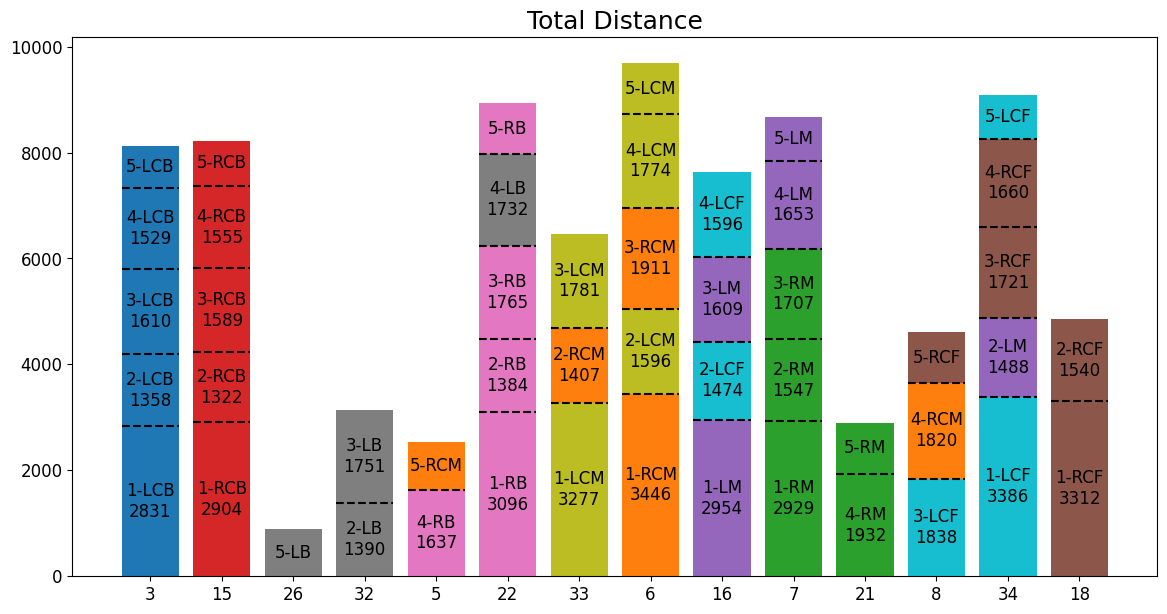

In [19]:
match.plot_by_player("distance", save=True)

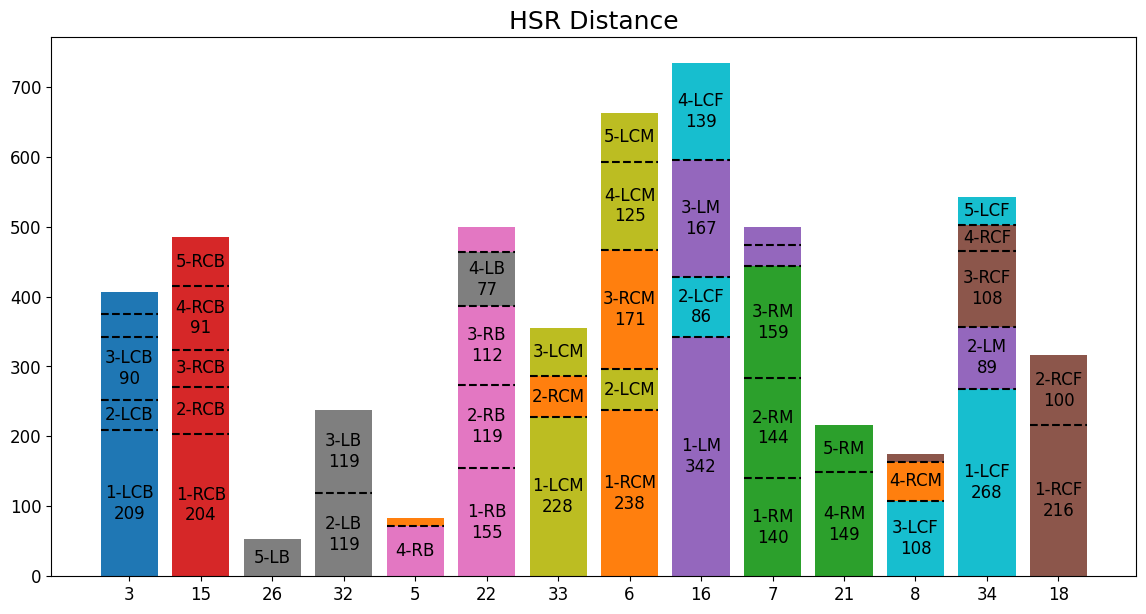

In [20]:
match.plot_by_player("hsr_dist", save=True)

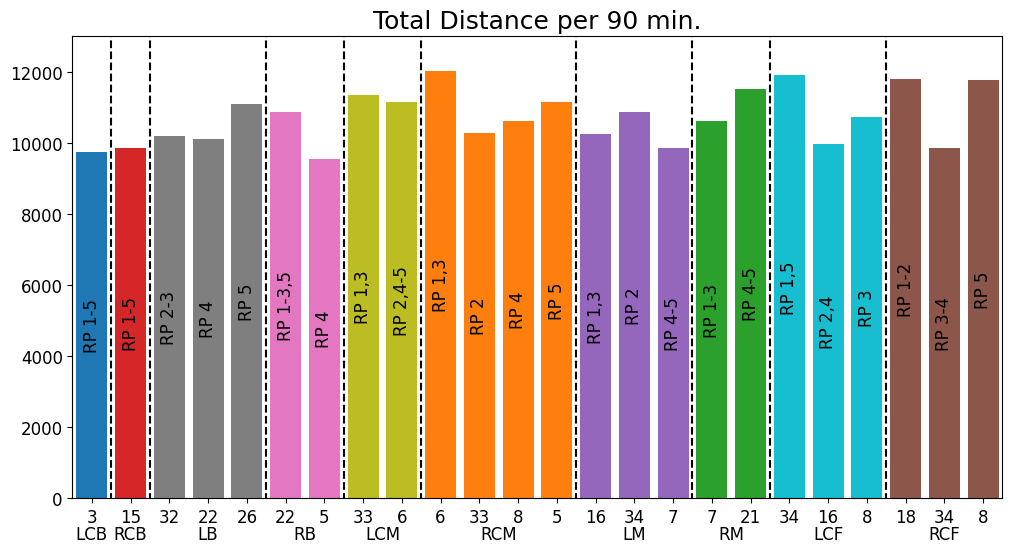

In [21]:
match.compute_role_stats()
match.plot_by_role("distance_90min", save=True)